# Multi-sample Pipeline: analyzing snATAC-seq data of human colon samples

## Introduction

In this tutorial, we will perform integrative analysis of snATAC-seq data of colon sample from multiple donors. 

In [2]:
import snapatac2 as snap

gene_annotation = "data/gencode.v39.basic.annotation.gff3.gz"

These are the fragment files we are going to analyze.

In [2]:
files = !ls data/*_fragments.bed.gz
files

['data/colon_transverse_SM-A9HOW_rep1_fragments.bed.gz',
 'data/colon_transverse_SM-A9VP4_rep1_fragments.bed.gz',
 'data/colon_transverse_SM-ACCQ1_rep1_fragments.bed.gz',
 'data/colon_transverse_SM-BZ2ZS_rep1_fragments.bed.gz',
 'data/colon_transverse_SM-CSSDA_rep1_fragments.bed.gz']

First we perform preprocessing for each dataset separately.

In [3]:
%%time
for fl in files:
    name = fl.split("/")[-1].split("_rep1_fragments")[0]
    data = snap.pp.import_data(
        fl,
        gene_annotation,                            
        snap.genome.hg38,
        file = name + ".h5ad",
    )
    snap.pp.filter_cells(data, min_tsse = 7, min_counts = 1000)
    snap.pp.make_tile_matrix(data)
    snap.pp.select_features(data)
    snap.pp.scrublet(data)
    snap.pp.call_doublets(data)
    data.close()

Simulating doublets...
Spectral embedding ...
Calculating doublet scores...
Simulating doublets...
Spectral embedding ...
Calculating doublet scores...
Simulating doublets...
Spectral embedding ...
Calculating doublet scores...
Simulating doublets...
Spectral embedding ...
Calculating doublet scores...
Simulating doublets...
Spectral embedding ...
Calculating doublet scores...
CPU times: user 24min 40s, sys: 1min 30s, total: 26min 11s
Wall time: 16min 12s


Let's collect the newly generated h5ad files and attach each of them with an unique identifier. We store this information in a list.

In [4]:
files = !ls colon*.h5ad
datasets = []
for fl in files:
    name = fl.split("/")[-1].split(".h5ad")[0]
    datasets.append((name, fl))
datasets

[('colon_transverse_SM-A9HOW', 'colon_transverse_SM-A9HOW.h5ad'),
 ('colon_transverse_SM-A9VP4', 'colon_transverse_SM-A9VP4.h5ad'),
 ('colon_transverse_SM-ACCQ1', 'colon_transverse_SM-ACCQ1.h5ad'),
 ('colon_transverse_SM-BZ2ZS', 'colon_transverse_SM-BZ2ZS.h5ad'),
 ('colon_transverse_SM-CSSDA', 'colon_transverse_SM-CSSDA.h5ad')]

## Creating AnnDataSet object

We then use `create_dataset` to create an `AnnDataSet` object which contains links to individual data. The data are not loaded into memory so it can scale to very large dataset.

In [5]:
%%time
data = snap.create_dataset(datasets, storage = "colon.h5ads")
data

CPU times: user 13.5 s, sys: 1.4 s, total: 14.9 s
Wall time: 15.9 s


AnnDataSet object with n_obs x n_vars = 41678 x 6176550 backed at 'colon.h5ads'
contains 5 AnnData objects with keys: colon_transverse_SM-A9HOW, colon_transverse_SM-A9VP4, colon_transverse_SM-ACCQ1, colon_transverse_SM-BZ2ZS, colon_transverse_SM-CSSDA
    obs: Cell, batch
    var: Feature_ID

Here we use a whitelist containing all peaks we previously identified in human tissues (Zhang et al., Cell, 2021) to filter the bins. This file can be downloaded using this [link](http://renlab.sdsc.edu/kai/Key_Processed_Data/cCRE_hg38.tsv.gz).

In [6]:
snap.pp.select_features(data, whitelist="data/cCRE_hg38.bed.gz")

Although this dataset is small enough to fit into memory, for illustration purpose we will show how to use subsampling to efficiently perform the dimension reduction. Subsampling significantly reduces the memory usage and speeds up the computation.

It is as simple as spectifying `sample_size=10000` in the `tl.spectral` function, which randomly selects 10,000 cells as the landmarks to get an initial embedding, and then uses the Nystrom method to compute the embedding for the rest of cells.

In [7]:
%%time
snap.tl.spectral(data, sample_size = 10000)

Compute similarity matrix
Normalization
Perform decomposition
Perform Nystrom extension


5it [01:03, 12.62s/it]                                                                                                                                                                                


CPU times: user 2min 51s, sys: 20.6 s, total: 3min 12s
Wall time: 1min 55s


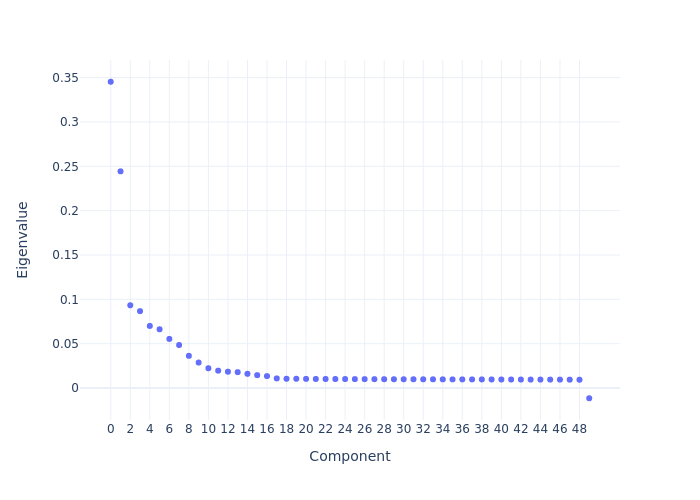

In [8]:
snap.pl.spectral_eigenvalues(data, interactive=False)

We next perform UMAP embedding and visualize the result.

In [9]:
snap.tl.umap(data, use_dims = 12)

/home/kaizhang/data/software/miniconda3/lib/python3.8/site-packages/umap/__init__.py:9: UserWarning:

Tensorflow not installed; ParametricUMAP will be unavailable



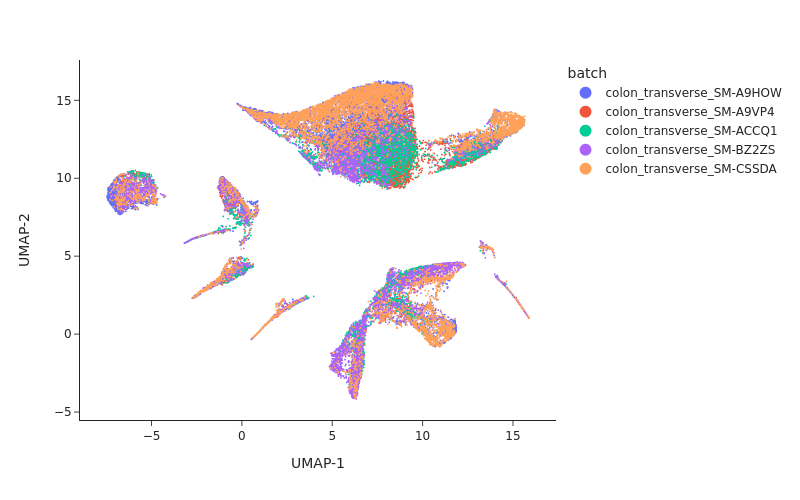

In [10]:
snap.pl.umap(data, color="batch", interactive=False, width = 800)

## Batch correction

From the UMAP plot above we can clearly see some donor/individual specific effects. Although these donor differences are interesting to study on their own, it obscures the clustering procedure for identifying shared cell states across individuals.

Here we apply two different approaches, Harmony and modified MNNCorrect, to remove donor specific differences.

In [12]:
%%time
snap.pp.mnc_correct(data, "batch", use_dims = 12)
snap.pp.harmony(data, "batch", use_dims = 12, max_iter_harmony = 20)

2022-04-12 13:15:06,441 - harmonypy - INFO - Iteration 1 of 20
2022-04-12 13:15:27,126 - harmonypy - INFO - Iteration 2 of 20
2022-04-12 13:15:50,397 - harmonypy - INFO - Iteration 3 of 20
2022-04-12 13:16:13,529 - harmonypy - INFO - Iteration 4 of 20
2022-04-12 13:16:39,792 - harmonypy - INFO - Iteration 5 of 20
2022-04-12 13:17:03,686 - harmonypy - INFO - Iteration 6 of 20
2022-04-12 13:17:28,782 - harmonypy - INFO - Iteration 7 of 20
2022-04-12 13:17:54,192 - harmonypy - INFO - Iteration 8 of 20
2022-04-12 13:18:19,267 - harmonypy - INFO - Iteration 9 of 20
2022-04-12 13:18:42,536 - harmonypy - INFO - Converged after 9 iterations


CPU times: user 8min 40s, sys: 7min 55s, total: 16min 35s
Wall time: 4min 27s


Visualizing the result of MNNCorrect.

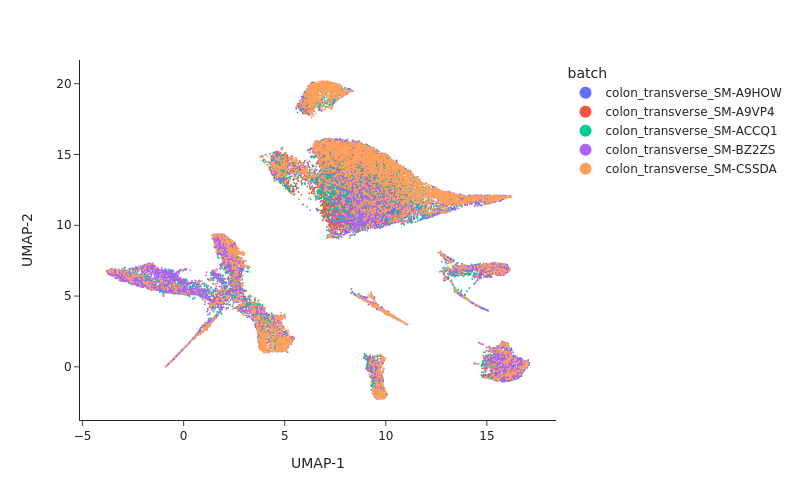

In [13]:
snap.tl.umap(data, use_rep="X_spectral_mnn")
snap.pl.umap(data, color="batch", interactive=False, width=800)

Visualize the result of Harmony.

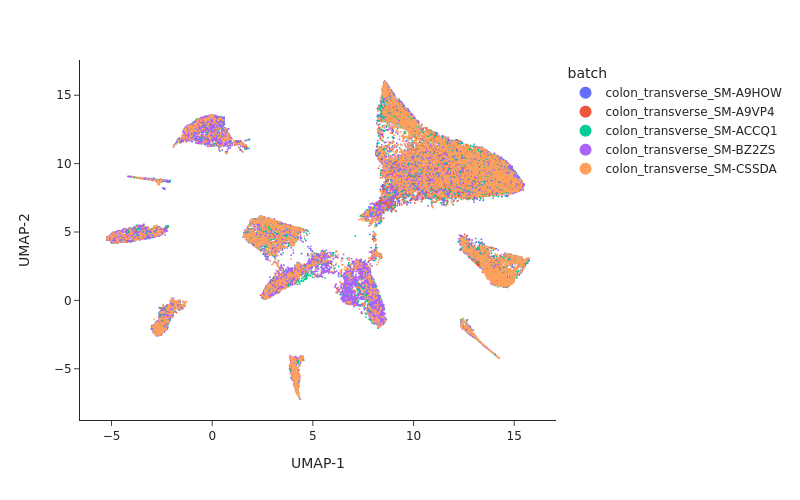

In [14]:
snap.tl.umap(data, use_rep="X_spectral_harmony")
snap.pl.umap(data, color="batch", interactive=False, width=800)

## Clustering

In [7]:
snap.pp.knn(data, use_rep="X_spectral_harmony", use_dims = 12)

In [16]:
snap.tl.leiden(data, resolution = 0.3)

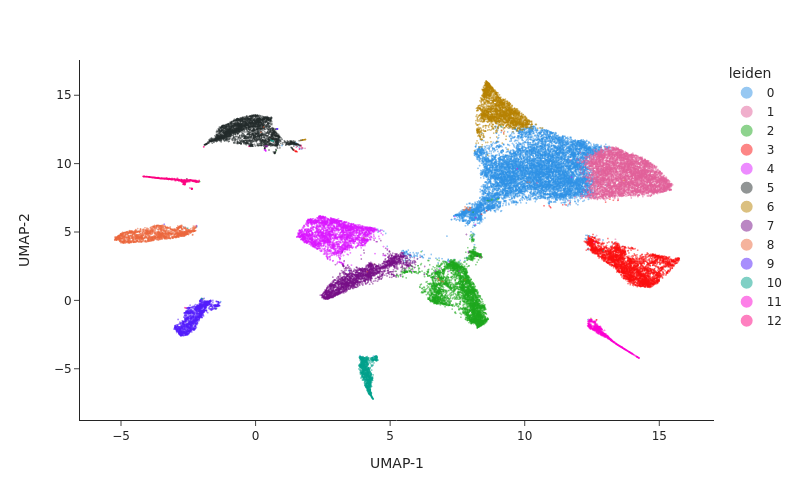

In [17]:
snap.pl.umap(data, color="leiden", interactive=False, width=800)

## AnnDataSet object IO

Just like the AnnData object, AnnDataSet object is synchronized with the content of the HDF5 file. Therefore, there is no need to manually save the result. After the analysis is finished, simply close the file by:

In [18]:
data.close()
data

Closed AnnDataSet object

The AnnDataSet object is stored as a standard h5ad file, in which the links to individual anndata file was saved in `uns['AnnDataSet']` and can be reopened by `snap.read_dataset`.

In [3]:
data = snap.read_dataset("colon.h5ads")
data

AnnDataSet object with n_obs x n_vars = 41678 x 6176550 backed at 'colon.h5ads'
contains 5 AnnData objects with keys: colon_transverse_SM-A9HOW, colon_transverse_SM-A9VP4, colon_transverse_SM-ACCQ1, colon_transverse_SM-BZ2ZS, colon_transverse_SM-CSSDA
    obs: Cell, batch
    var: Feature_ID, selected
    obsm: X_umap, X_spectral_harmony, X_spectral, X_spectral_mnn

Because the AnnDataSet object does not copy the underlying AnnData objects, if you move the component h5ad files then it won't be able to find them. In this case, you can supply the new locations using the `data_files` variable:

In [17]:
data.close()
data = snap.read_dataset("colon.h5ads", data_files = {"colon_transverse_SM-CSSDA": "colon_transverse_SM-CSSDA.h5ad"})
data

AnnDataSet object with n_obs x n_vars = 41678 x 6176550 backed at 'colon.h5ads'
contains 5 AnnData objects with keys: colon_transverse_SM-A9HOW, colon_transverse_SM-A9VP4, colon_transverse_SM-ACCQ1, colon_transverse_SM-BZ2ZS, colon_transverse_SM-CSSDA
    obs: Cell, batch
    var: Feature_ID, selected
    obsm: X_spectral, X_umap, X_spectral_mnn, X_spectral_harmony